In [1]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.family']

mall = pd.read_csv('C:/medicalAI/Pycham/week3/Data_processing/unsupervised/Mall_Customers.csv')
mall.describe()

,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [16]:
#calculate 25th, 75th percentile, Sort outliers in ascednding order
#IQR = Q3-Q1
x = mall['Annual Income']
Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
print(Q1,  Q3)
IQR = Q3-Q1

41.5 78.0


In [4]:
low, high = Q1 - 1.5* IQR, Q3 +1.5*IQR
print(low, high)

-13.25 132.75


In [6]:
outliers = mall[(x< low)| (x>high)]
print(f'inlier:{low:.0f}-{high:.0f}/outliers{len(outliers)}')

inlier:-13-133/outliers2


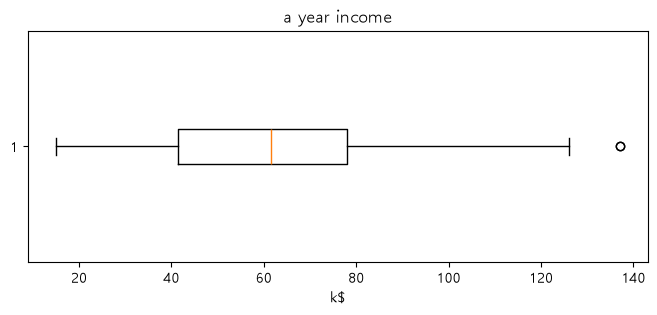

In [9]:
plt.figure(figsize=(8, 3))
plt.boxplot(x, orientation='horizontal')  #만약 세로 방향 박스플롯을 그리려면 orientation='vertical'을 사용
plt.title('a year income')
plt.xlabel('k$')
plt.show()

In [10]:
#z-score(mean, standard Deefiatione= σ)
z = (x-x.mean()) / x.std()  #distaance of mean
# z>3 at mean over SD=3  = outlier
mall['income_z']=z
print('z>3 outlier:', (z.abs() > 3).sum())



z>3 outlier: 0


In [11]:
#z score top 5
print(mall.loc[z.abs().sort_values(ascending=False).index[:5],['Annual Income']])

     Annual Income
199            137
198            137
197            126
196            126
195            120


In [30]:
mall_clean = mall[(mall['income_z'] <= 3).values]
std_val_mall = mall_clean['Annual Income'].std()
print(f'std: {std_val_mall:.2f}')

std: 26.26


In [ ]:
#std: 26.26 means
#고객 타겟팅 기준 설정: 평균 $\pm$ 26.26 범위 내에 있는 고객을 '주요/일반 고객군'으로 정의할 수 있습니다.

# california house dataset

In [17]:
housing = pd.read_csv('C:/medicalAI/Pycham/week3/Data_processing/housing/housing.csv')
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


longitude: 경도
latitude: 위도
housing_median_Age: 주택 연식 중앙값

In [18]:

x = housing['median_house_value']
Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
print(Q1,  Q3)
IQR = Q3-Q1

119600.0 264725.0


In [19]:
low, high = Q1 - 1.5* IQR, Q3 +1.5*IQR
print(low, high)

-98087.5 482412.5


In [21]:
outliers = housing[(x< low)| (x>high)]
print(f'inlier:{low:.0f}-{high:.0f}/outliers{len(outliers)}')

inlier:-98088-482412/outliers1071


In [22]:
# Z-Score 계산
z = (housing['median_house_value'] - housing['median_house_value'].mean()) / housing['median_house_value'].std()

# |Z| <= 3 인 정상 데이터만 추출
housing_clean = housing[z.abs() <= 3]

In [23]:
std_val = housing_clean['median_house_value'].std()
print(f'std: {std_val:.2f}')

std: 115395.62


In [ ]:
#즉, "캘리포니아 주택 시장은 동네(위치)에 따른 가격 양극화가 매우 극심하다"라고 해석할 수 있습니다.